# Поиск данных

Тут будем смотреть на датасеты и выбирать промежутки, на которых будем строить модели. \
Результат сохраняем в папку Data

In [21]:
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd
import yfinance as yf

# 1. Кросы

In [22]:
# 1. Задаем тикеры и период (например, последние 5 лет)
tickers = {"Nike": "NKE", "Puma": "PUM.DE"}
start_date = "2019-01-01"
end_date = "2026-10-01"  # Текущая дата

# 2. Загружаем данные (используем цену закрытия 'Close')
data = yf.download(list(tickers.values()), start=start_date, end=end_date)["Close"]
data.columns = list(tickers.keys())  # Переименовываем колонки для удобства
data.head()

[*********************100%***********************]  1 of 2 completed


,Nike,Puma
Date,,
2019-01-02,65.859970,40.040970
2019-01-03,64.695000,39.671928
2019-01-04,66.384644,41.471004
2019-01-07,67.336166,40.825180
2019-01-08,68.234344,41.055836


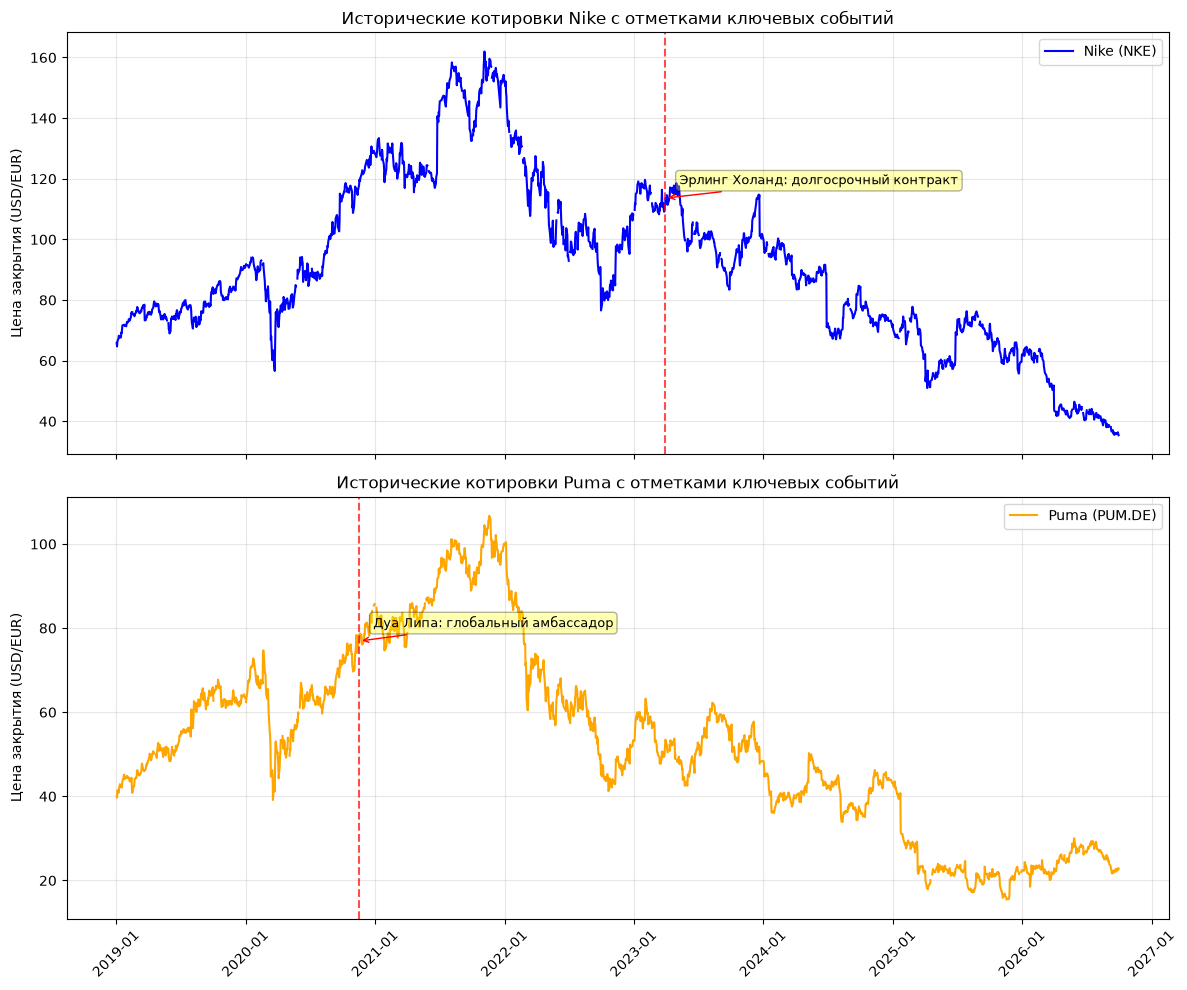

In [23]:
fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# События: (Дата, Компания, Описание)
# TODO докинуть сюда больше событий
events = [
    ("2020-11-17", "Puma", "Дуа Липа: глобальный амбассадор"),
    ("2023-03-31", "Nike", "Эрлинг Холанд: долгосрочный контракт"),
]

colors = {"Nike": "blue", "Puma": "orange"}

for i, (company, ticker_col) in enumerate(tickers.items()):
    ax = axes[i]
    ax.plot(
        data.index,
        data[company],
        label=f"{company} ({ticker_col})",
        color=colors[company],
        linewidth=1.5,
    )

    # Добавляем вертикальные линии для событий, относящихся к этой компании
    for date, evt_company, desc in events:
        if evt_company == company:
            ax.axvline(pd.to_datetime(date), color="red", linestyle="--", alpha=0.7)
            # Добавляем текст аннотации
            ax.annotate(
                desc,
                xy=(pd.to_datetime(date), data[company].asof(date)),
                xytext=(10, 10),
                textcoords="offset points",
                arrowprops={"arrowstyle": "->", "color": "red"},
                fontsize=9,
                bbox={"boxstyle": "round,pad=0.3", "fc": "yellow", "alpha": 0.3},
            )

    ax.set_title(f"Исторические котировки {company} с отметками ключевых событий")
    ax.set_ylabel("Цена закрытия (USD/EUR)")
    ax.legend()
    ax.grid(True, alpha=0.3)

# Форматируем ось X для красоты
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [25]:
# TODO вырезать нужный кусок данных, пока сохраним целиком
data.to_csv("Data/sneakers_data.csv")

# 2. Автопром

In [26]:
# 1. Тикеры
tickers = {"Volkswagen": "VOW3.DE", "Renault": "RNO.PA", "Li Auto": "LI", "NIO": "NIO"}

# 2. Загружаем данные (с запасом до событий)
start_date = "2021-01-01"
end_date = "2026-10-01"

data = yf.download(list(tickers.values()), start=start_date, end=end_date)["Close"]
data.columns = list(tickers.keys())

# Проверяем, что всё загрузилось
print(data.tail())
print("\nПропуски в данных:")
print(data.isna().sum())

[*********************100%***********************]  4 of 4 completed

            Volkswagen  Renault    Li Auto        NIO
Date                                                 
2026-09-24       11.78     3.63  26.150000  70.820000
2026-09-25       11.50     3.58  26.299999  71.720001
2026-09-28       11.71     3.59  26.330000  70.879997
2026-09-29       11.23     3.40  26.059999  71.040001
2026-09-30       11.36     3.43  25.900000  70.459999

Пропуски в данных:
Volkswagen    43
Renault       43
Li Auto       13
NIO           20
dtype: int64


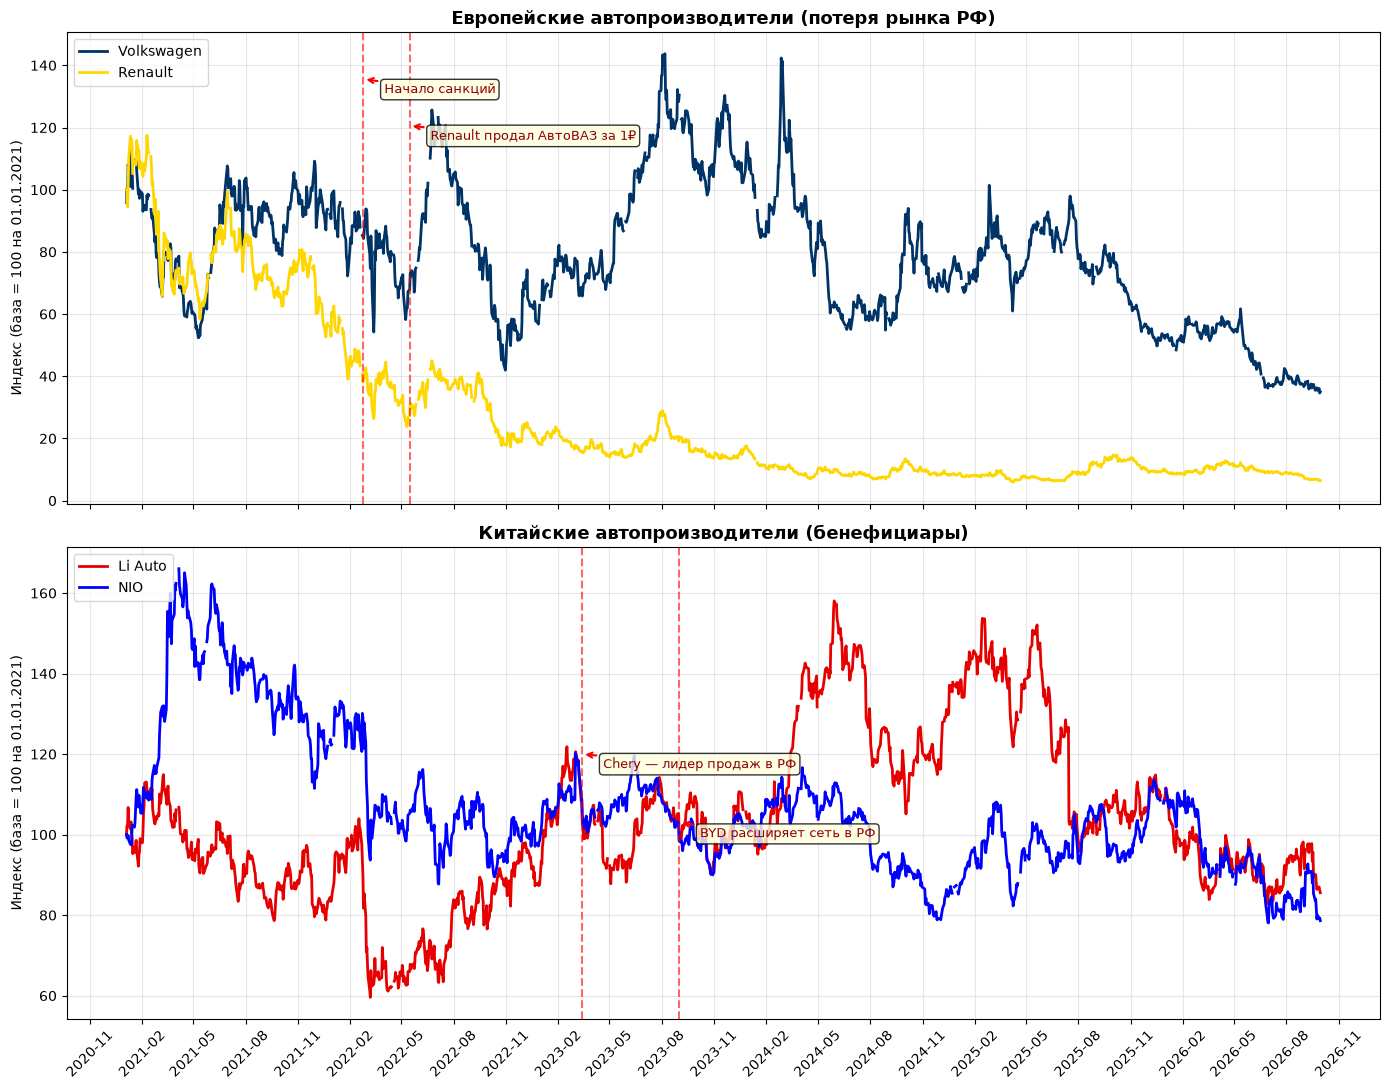

In [27]:
# События: (дата, группа, описание)
events = [
    ("2022-02-24", "EU", "Начало санкций"),
    ("2022-05-16", "EU", "Renault продал АвтоВАЗ за 1₽"),
    ("2023-03-15", "CN", "Chery — лидер продаж в РФ"),
    ("2023-09-01", "CN", "BYD расширяет сеть в РФ"),
]

# Нормализуем цены к 100 на начало периода для сравнения динамики
data_norm = data.div(data.iloc[0]) * 100

fig, axes = plt.subplots(2, 1, figsize=(14, 11), sharex=True)

# Группы компаний
groups = {
    "Европейские автопроизводители (потеря рынка РФ)": ["Volkswagen", "Renault"],
    "Китайские автопроизводители (бенефициары)": ["Li Auto", "NIO"],
}
colors = {
    "Volkswagen": "#003366",
    "Renault": "#FFD700",
    "Li Auto": "#E60000",
    "NIO": "#0000FF",
}

for i, (title, companies) in enumerate(groups.items()):
    ax = axes[i]

    for company in companies:
        ax.plot(
            data_norm.index,
            data_norm[company],
            label=company,
            color=colors[company],
            linewidth=2,
        )

    # Размечаем события
    group_tag = "EU" if i == 0 else "CN"
    for i, (date, evt_group, desc) in enumerate(events):
        if evt_group == group_tag:
            ax.axvline(
                pd.to_datetime(date),
                color="red",
                linestyle="--",
                alpha=0.6,
                linewidth=1.5,
            )
            # Аннотация
            y_pos = ax.get_ylim()[1] * (0.9 - 0.1 * (i))
            ax.annotate(
                desc,
                xy=(pd.to_datetime(date), y_pos),
                xytext=(15, -10),
                textcoords="offset points",
                arrowprops={"arrowstyle": "->", "color": "red", "lw": 1.5},
                fontsize=9,
                color="darkred",
                bbox={"boxstyle": "round,pad=0.3", "fc": "lightyellow", "alpha": 0.8},
            )

    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_ylabel("Индекс (база = 100 на 01.01.2021)")
    ax.legend(loc="upper left")
    ax.grid(True, alpha=0.3)

# Форматирование оси X
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [28]:
# TODO аналогично сделать вырезку
data.to_csv("Data/car_data.csv")